# Atividade Prática 3

Aluno: João Gabriel Angelo Bradachi

Professor: Fabrício Silva

Objetivo: Aplicar técnicas de transformação nos dados para melhorar treinamento de Modelos


In [6]:
! pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 3.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 2.4 MB/s eta 0:00:00m eta 0:00:010:00:07


In [9]:
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [10]:
churn_raw = pd.read_csv("Churn_Bank.csv")
churn_raw

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
churn_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [12]:
churn_raw.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


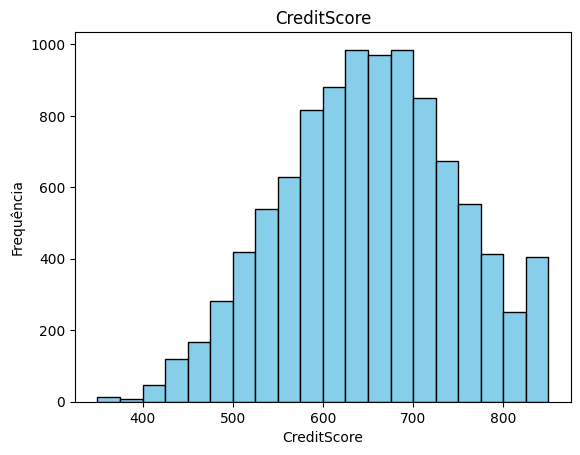

In [18]:
plt.hist(churn_raw['CreditScore'], bins=20, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

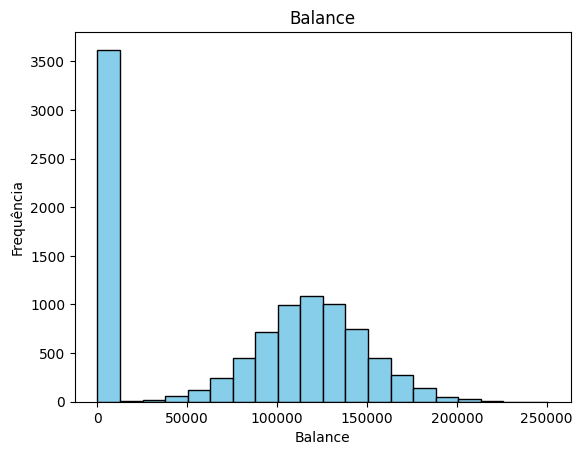

In [19]:
plt.hist(churn_raw['Balance'], bins=20, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('Balance')
plt.xlabel('Balance')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

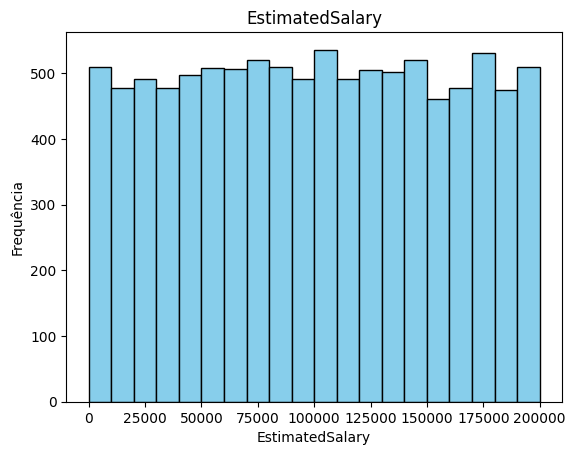

In [22]:
plt.hist(churn_raw['EstimatedSalary'], bins=20, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('EstimatedSalary')
plt.xlabel('EstimatedSalary')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

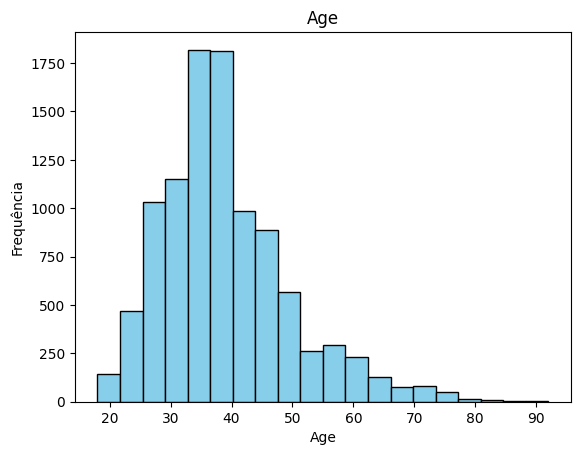

In [23]:
plt.hist(churn_raw['Age'], bins=20, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('Age')
plt.xlabel('Age')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

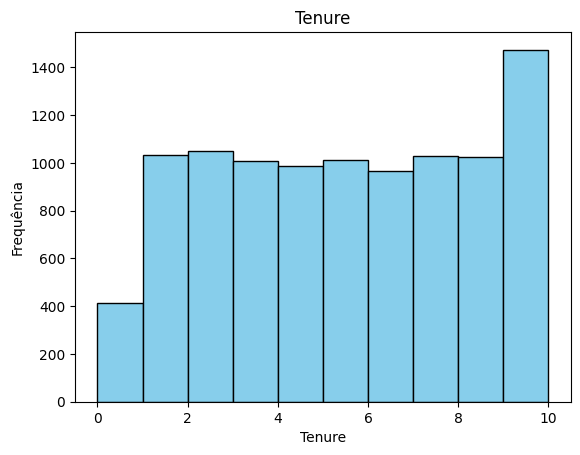

In [25]:
plt.hist(churn_raw['Tenure'], bins=10, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('Tenure')
plt.xlabel('Tenure')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

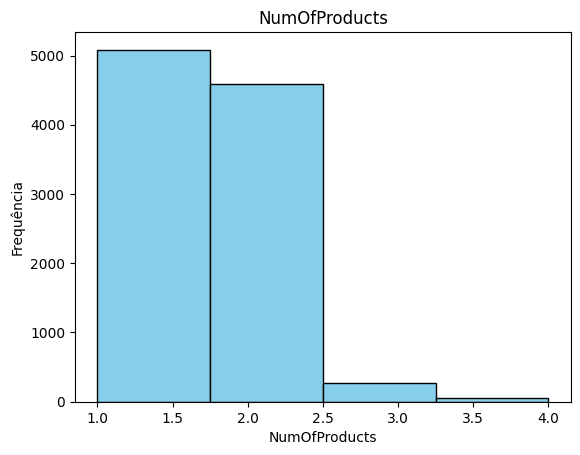

In [27]:
plt.hist(churn_raw['NumOfProducts'], bins=4, color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('NumOfProducts')
plt.xlabel('NumOfProducts')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

## Análise prévia dos dados
* algumas colunas são booleanas, HasCrCard, IsActiveMember, Exited
* Tenure e num of products podem ser categóricas 
* podemos colocar balance, age, creditScore e EstimatedSalary em bins
* podemos remover RowNumber e CostumerID
* podemos criar uma categoria a mais no surname juntando todos os sobrenomes que aparecem apenas uma vez (chamar de "outros")

Mas vamos tentar fazer a previsão usando o dataset todo sem nenhuma engenharia de dados. Vamos usar o XGBoost

In [8]:
df_nao_tratado = churn_raw.dropna()
df_nao_tratado

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [15]:


X = df_nao_tratado.drop('Exited', axis=1) 
y = df_nao_tratado['Exited']              

# Dividindo em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
y_treino = y_treino.astype(bool)

# Pega o nome das colunas numéricas (int e float)
colunas_numericas = X.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()

# Pega o nome das colunas categóricas (object/string)
colunas_categoricas = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# Pipeline para categorias: aplica One-Hot Encoding
transformer_categorico = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore: se aparecer uma categoria nova no teste, ele não quebra
])

# ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('cat', transformer_categorico, colunas_categoricas)
    ])

# Aqui conectamos o tratamento de dados ao modelo Random Forest
modelo_pipeline = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('classificador', XGBClassifier(
        n_estimators=100,     # Número de árvores
        learning_rate=0.1,    # Velocidade de aprendizado (ajuda a não ter overfitting)
        max_depth=5,          # Profundidade máxima de cada árvore
        random_state=42
    ))
])

print("Treinando o modelo...")
modelo_pipeline.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

           0    0.80390   1.00000   0.89129      1607
           1    1.00000   0.00254   0.00508       393

    accuracy                        0.80400      2000
   macro avg    0.90195   0.50127   0.44818      2000
weighted avg    0.84244   0.80400   0.71715      2000



## Melhorando a partir dos atributos numéricos

In [ ]:
df_tratado = churn_raw.drop(columns=['CustomerId', 'RowNumber'])